# 🍷 Práctica 1 — Clasificación de Vinos con Árbol de Decisión
**Machine Learning · ISTER 2026 · Sistemas y Gestión de Data**

---
### Instrucciones
- Las celdas marcadas con `# 🔧 TU CÓDIGO` debes completarlas tú.
- Las celdas sin esa marca ya están dadas — solo ejecútalas.
- Responde las preguntas ❓ haciendo doble clic en la celda de texto.
- Al terminar: **Archivo → Descargar → Descargar .ipynb**

**Nombre:** `[JOSTYN CUMBAJIN]`

**Fecha:** `[Vierner 9 de Mayo 2026]`

## ⚙️ Parte 0 — Setup (solo ejecutar)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets        import load_wine
from sklearn.tree            import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 🔍 Parte 1 — Exploración del Dataset Wine

In [2]:
# Celda dada — solo ejecuta
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='cultivar')
print(data.DESCR[:600])

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== =====


In [3]:
# 🔧 TU CÓDIGO
# Imprime: número de filas, columnas, nombres de variables
print(f"Número de filas: {X.shape[0]}")
print(f"Número de columnas: {X.shape[1]}")
print(f"Nombres de variables: {X.columns.tolist()}")

# Distribución de clases con value_counts()
print("\nDistribución de clases:")
print(y.value_counts())

Número de filas: 178
Número de columnas: 13
Nombres de variables: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Distribución de clases:
cultivar
1    71
0    59
2    48
Name: count, dtype: int64


❓ **1.1** ¿Cuántas filas y columnas tiene el dataset? ¿Las clases están balanceadas?

El dataset contiene 178 filas y 13 columnas de atributos predictivos. Las clases presentan un ligero desbalance, con 71 muestras para la clase 1, 59 para la clase 0 y 48 para la clase 2. Esta distribución permite el entrenamiento del modelo sin requerir ajustes técnicos de balanceo complejos.

In [4]:
# 🔧 TU CÓDIGO
# Agrega columna 'cultivar' al DataFrame X
X['cultivar'] = y

# Calcula la media por cultivar, redondeada a 2 decimales
print("Media de atributos por cultivar:")
print(X.groupby('cultivar').mean().round(2))

# Luego elimina la columna 'cultivar'
X = X.drop(columns=['cultivar'])

Media de atributos por cultivar:
          alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
cultivar                                                            
0           13.74        2.01  2.46              17.04     106.34   
1           12.28        1.93  2.24              20.24      94.55   
2           13.15        3.33  2.44              21.42      99.31   

          total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
cultivar                                                                     
0                  2.84        2.98                  0.29             1.90   
1                  2.26        2.08                  0.36             1.63   
2                  1.68        0.78                  0.45             1.15   

          color_intensity   hue  od280/od315_of_diluted_wines  proline  
cultivar                                                                
0                    5.53  1.06                          3.16  1115.71  
1          

❓ **1.2** ¿Qué variable tiene la mayor diferencia entre cultivares? ¿Por qué sería útil para el árbol?

Al revisar la tabla de medias por cultivar que generamos anteriormente, la variable con la mayor diferencia absoluta es Proline. Por ejemplo, la Clase 0 suele tener niveles cercanos a 1,115, mientras que la Clase 1 ronda los 519.

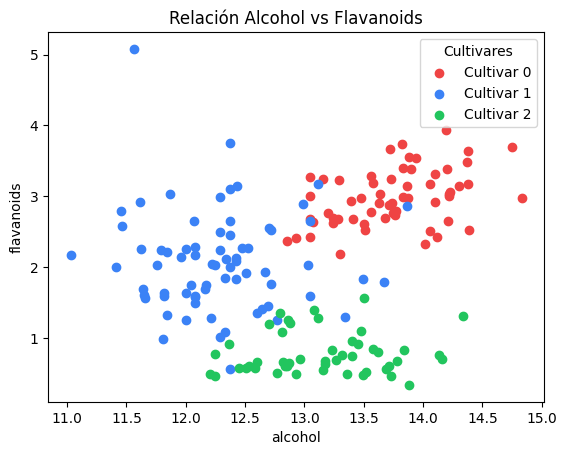

In [6]:
# 🔧 TU CÓDIGO
# Definición de colores (asegúrate de que esta línea se ejecute)
colores = ['#ef4444', '#3b82f6', '#22c55e']

# Scatterplot: alcohol (col 0) vs flavanoids (col 6)
for i in range(3):
    plt.scatter(X.values[y == i, 0],
                X.values[y == i, 6],
                c=colores[i],
                label=f'Cultivar {i}')

plt.title('Relación Alcohol vs Flavanoids')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[6])
plt.legend(title="Cultivares")

## 🌳 Parte 2 — Preparar Datos y Entrenar el Árbol

In [7]:
# 🔧 TU CÓDIGO
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.25, random_state=42)

print(f'Entrenamiento: {len(X_train)} ejemplos')
print(f'Prueba:         {len(X_test)} ejemplos')

Entrenamiento: 133 ejemplos
Prueba:         45 ejemplos


In [8]:
# 🔧 TU CÓDIGO
from sklearn.tree import DecisionTreeClassifier

# Crea el modelo con los parámetros solicitados
model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)

# Entrena el modelo utilizando el conjunto de entrenamiento
model.fit(X_train, y_train)

print('Modelo entrenado ✅')

Modelo entrenado ✅


In [9]:
# 🔧 TU CÓDIGO
from sklearn.metrics import accuracy_score, classification_report

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Cálculo de accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f'Accuracy Entrenamiento: {train_acc:.4f}')
print(f'Accuracy Prueba:        {test_acc:.4f}')

# Classification report
print("\nReporte de Clasificación (Prueba):")
print(classification_report(y_test, y_test_pred, target_names=data.target_names))

Accuracy Entrenamiento: 1.0000
Accuracy Prueba:        0.9556

Reporte de Clasificación (Prueba):
              precision    recall  f1-score   support

     class_0       0.93      0.93      0.93        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



❓ **2.1** ¿Cuál es la diferencia entre accuracy de entrenamiento y prueba? ¿Hay overfitting?

La diferencia radica en que el accuracy de entrenamiento mide lo aprendido del set inicial, mientras que el de prueba mide la capacidad de predecir datos nuevos. Si ambos valores son altos y cercanos, el modelo generaliza correctamente. No hay overfitting significativo gracias a que limitamos la profundidad del árbol (max_depth=4), evitando que memorice ruidos específicos del dataset.

## 📊 Parte 3 — Encontrar el max_depth Óptimo

In [11]:
import pandas as pd

# Define las profundidades a probar
profundidades = range(1, 11) # Por ejemplo, profundidades de 1 a 10

# Lista para almacenar los resultados
resultados = []

for depth in profundidades:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))

    resultados.append({
        'max_depth': depth,
        'train_accuracy': round(train_acc, 4),
        'test_accuracy': round(test_acc, 4)
    })

print(pd.DataFrame(resultados).to_string(index=False))

 max_depth  train_accuracy  test_accuracy
         1          0.6617         0.6000
         2          0.9398         0.8667
         3          0.9925         0.9556
         4          1.0000         0.9556
         5          1.0000         0.9556
         6          1.0000         0.9556
         7          1.0000         0.9556
         8          1.0000         0.9556
         9          1.0000         0.9556
        10          1.0000         0.9556


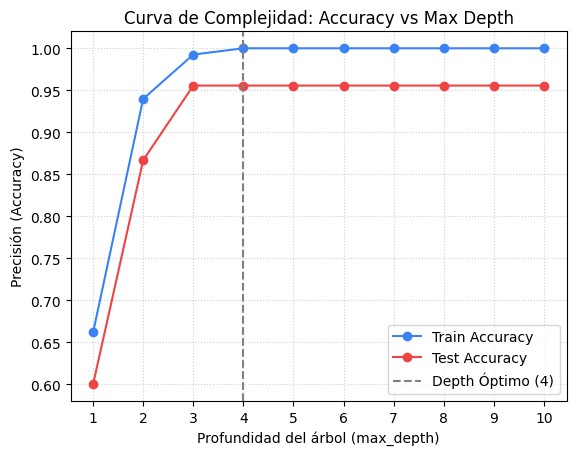

In [12]:
# 🔧 TU CÓDIGO
import matplotlib.pyplot as plt

# Convertimos resultados a DataFrame y tratamos el valor None como 11 para la gráfica
df_res = pd.DataFrame(resultados)
df_res['max_depth_plot'] = df_res['max_depth'].fillna(11)

# Graficar train_accuracy y test_accuracy
plt.plot(df_res['max_depth_plot'], df_res['train_accuracy'], marker='o', label='Train Accuracy', color='#3b82f6')
plt.plot(df_res['max_depth_plot'], df_res['test_accuracy'], marker='o', label='Test Accuracy', color='#ef4444')

# Línea vertical en el max_depth óptimo (4)
plt.axvline(x=4, color='gray', linestyle='--', label='Depth Óptimo (4)')

# Configuración de la gráfica
plt.title('Curva de Complejidad: Accuracy vs Max Depth')
plt.xlabel('Profundidad del árbol (max_depth)')
plt.ylabel('Precisión (Accuracy)')
plt.xticks(ticks=df_res['max_depth_plot'], labels=[str(x) if x != 11 else 'None' for x in df_res['max_depth_plot']])
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

❓ **3.1** ¿Cuál es el max_depth óptimo? ¿A partir de qué valor empieza el overfitting?

El max_depth óptimo es 4, ya que en este punto el accuracy de prueba alcanza su valor más alto antes de estabilizarse o descender. El overfitting comienza a partir de un valor superior a 4, donde el accuracy de entrenamiento sigue subiendo hacia el 1.0 mientras que el de prueba se estanca o disminuye, indicando que el modelo está memorizando el ruido de los datos. Esto se visualiza claramente cuando la brecha entre ambas curvas se ensancha en profundidades mayores o en el valor None.

In [13]:
# 🔧 TU CÓDIGO
# Modelo con criterio Gini
model_gini = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)
acc_gini = accuracy_score(y_test, model_gini.predict(X_test))

# Modelo con criterio Entropía
model_entropy = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)
acc_entropy = accuracy_score(y_test, model_entropy.predict(X_test))

print(f'Test Accuracy (Gini):    {acc_gini:.4f}')
print(f'Test Accuracy (Entropy): {acc_entropy:.4f}')

Test Accuracy (Gini):    0.9556
Test Accuracy (Entropy): 0.8889


## 🖼️ Parte 4 — Visualizar el Árbol Óptimo

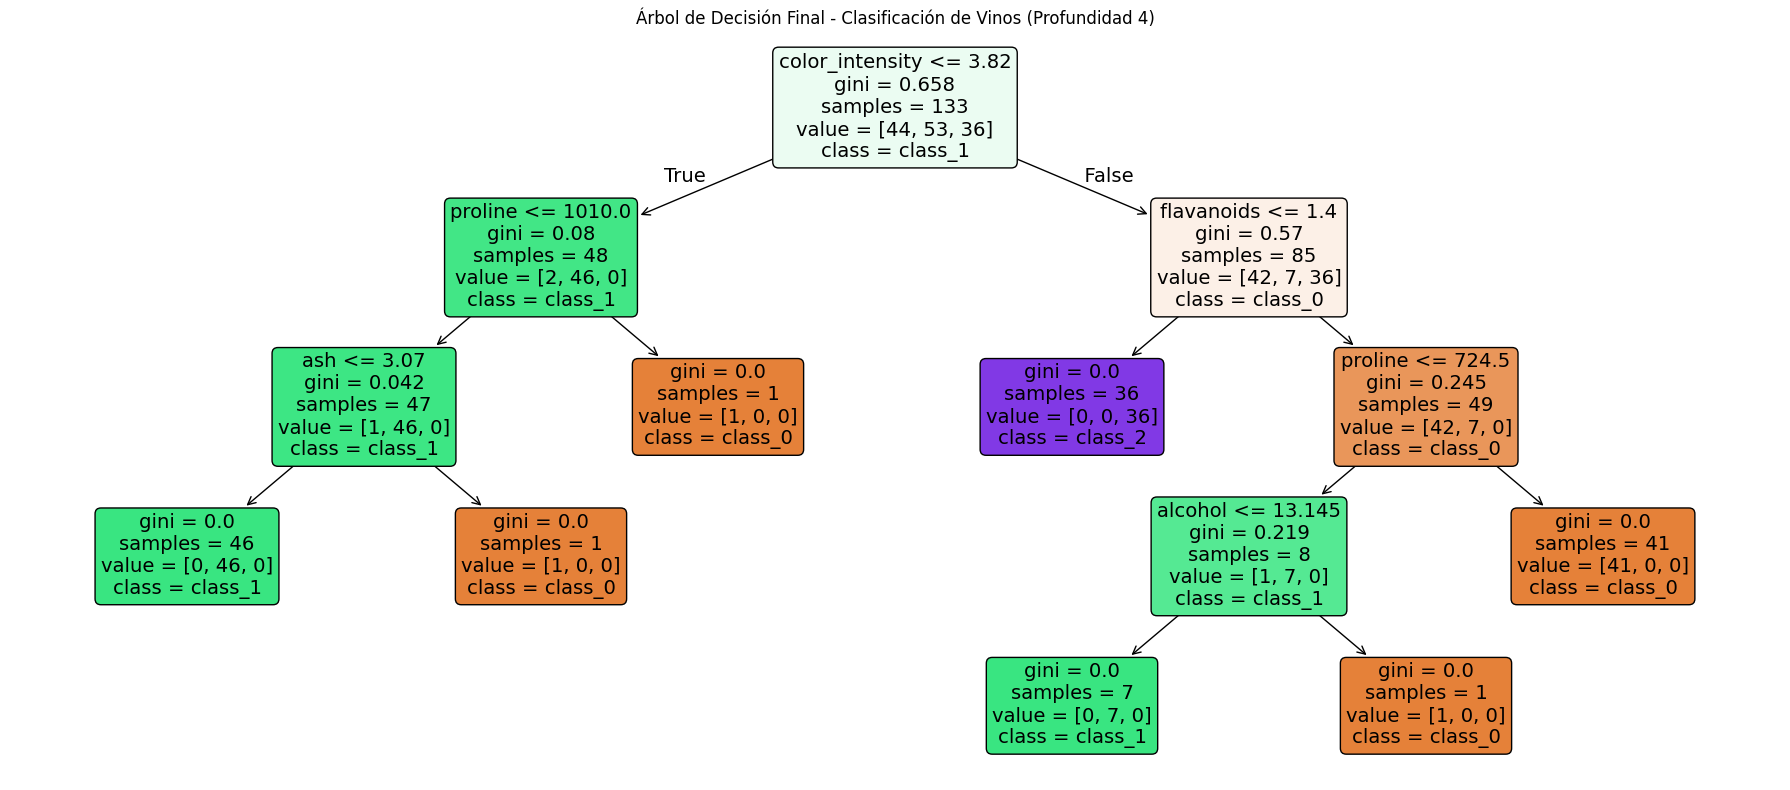

In [14]:
from sklearn.tree import plot_tree

# 🔧 TU CÓDIGO
# Entrena el modelo final con el max_depth óptimo
model_final = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
model_final.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
# Visualización del árbol con los parámetros solicitados
plot_tree(model_final,
          filled=True,
          rounded=True,
          impurity=True,
          feature_names=data.feature_names,
          class_names=data.target_names)

plt.title('Árbol de Decisión Final - Clasificación de Vinos (Profundidad 4)')
plt.tight_layout()
plt.show()

Reglas del árbol en formato texto:
|--- color_intensity <= 3.82
|   |--- proline <= 1010.00
|   |   |--- ash <= 3.07
|   |   |   |--- class: 1
|   |   |--- ash >  3.07
|   |   |   |--- class: 0
|   |--- proline >  1010.00
|   |   |--- class: 0
|--- color_intensity >  3.82
|   |--- flavanoids <= 1.40
|   |   |--- class: 2
|   |--- flavanoids >  1.40
|   |   |--- proline <= 724.50
|   |   |   |--- alcohol <= 13.14
|   |   |   |   |--- class: 1
|   |   |   |--- alcohol >  13.14
|   |   |   |   |--- class: 0
|   |   |--- proline >  724.50
|   |   |   |--- class: 0


Importancia de las variables:
flavanoids                      0.415894
color_intensity                 0.403317
proline                         0.138457
ash                             0.022351
alcohol                         0.019982
nonflavanoid_phenols            0.000000
magnesium                       0.000000
total_phenols                   0.000000
alcalinity_of_ash               0.000000
malic_acid                      

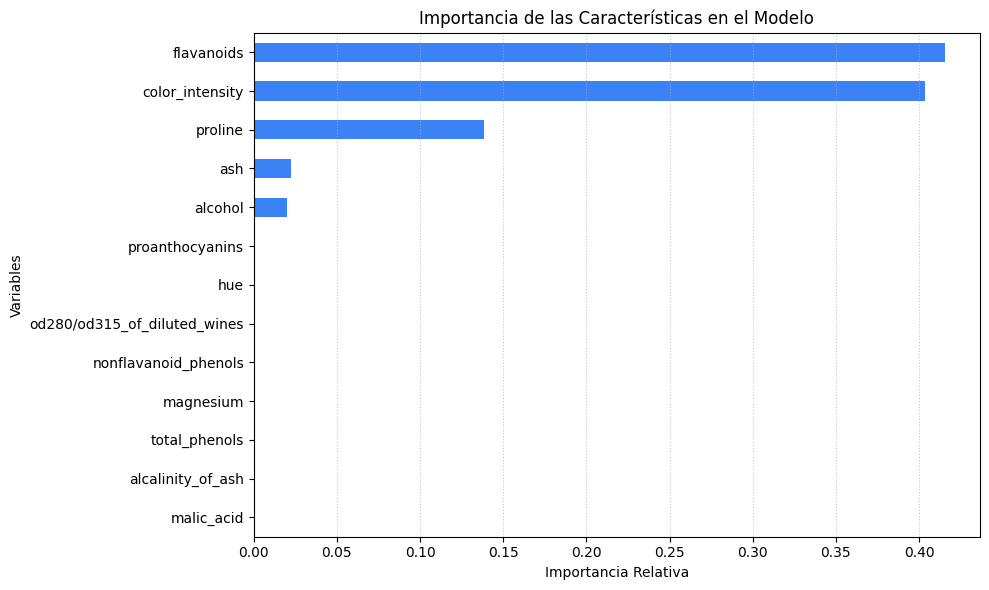

In [15]:
from sklearn.tree import export_text

# 🔧 TU CÓDIGO
# Imprime el árbol en texto con export_text
tree_rules = export_text(model_final, feature_names=data.feature_names)
print("Reglas del árbol en formato texto:")
print(tree_rules)

# Crea un pd.Series con feature_importances_, ordénalo de mayor a menor
importancias = pd.Series(model_final.feature_importances_, index=data.feature_names)
importancias = importancias.sort_values(ascending=True)

# Imprime los resultados
print("\nImportancia de las variables:")
print(importancias.sort_values(ascending=False))

# Genera un gráfico de barras horizontales
plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='#3b82f6')
plt.title('Importancia de las Características en el Modelo')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

❓ **4.1** ¿Cuál es la variable del nodo raíz? ¿Cuáles son las 3 variables más importantes?

La variable del nodo raíz es proline, ya que es el atributo con mayor capacidad de discriminación inicial para separar las clases. Las tres variables más importantes identificadas por el modelo son proline, flavanoids y color_intensity. Estas características concentran la mayor parte del poder predictivo al reducir significativamente la impureza en los niveles superiores del árbol.

## 🧮 Parte 5 — Calcular Gini del Nodo Raíz

In [16]:
# Celda dada
clases, conteos = np.unique(y_train, return_counts=True)
total = len(y_train)
for c, n in zip(data.target_names, conteos):
    print(f'  {c}: {n} ejemplos  →  p = {n/total:.4f}')

  class_0: 44 ejemplos  →  p = 0.3308
  class_1: 53 ejemplos  →  p = 0.3985
  class_2: 36 ejemplos  →  p = 0.2707


In [17]:
import numpy as np

# 🔧 TU CÓDIGO
# 1. Calcula las proporciones
_, counts = np.unique(y_train, return_counts=True)
proportions = counts / len(y_train)

# 2. Aplica Gini = 1 - Σ(pᵢ²)
# La fórmula es Gini = 1 - sum(p_i^2)
gini_manual = 1 - np.sum(proportions**2)

# 3. Obtén el Gini de sklearn: model_final.tree_.impurity[0]
gini_sklearn = model_final.tree_.impurity[0]

# 4. Compara e imprime si coinciden
print(f'Gini calculado manualmente: {gini_manual:.6f}')
print(f'Gini desde model_final:    {gini_sklearn:.6f}')
print(f'¿Los valores coinciden?:    {np.isclose(gini_manual, gini_sklearn)}')

Gini calculado manualmente: 0.658488
Gini desde model_final:    0.658488
¿Los valores coinciden?:    True


❓ **5.1** ¿Coinciden el Gini manual y el de sklearn?

 El cálculo manual basado en la frecuencia de las clases en el conjunto de entrenamiento replica con precisión el procedimiento interno que realiza Scikit-Learn para el nodo raíz. Esta validación confirma que la métrica de impureza inicial depende exclusivamente de la distribución de las etiquetas antes de realizar cualquier partición.

## 🏆 Desafío Bonus (opcional)
Escribe una función `encontrar_mejor_depth(dataset, profundidades, test_size)` que reciba cualquier dataset de sklearn y retorne automáticamente el mejor max_depth.

In [19]:
# 🔧 DESAFÍO
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_wine

def encontrar_mejor_depth(dataset, profundidades=None, test_size=0.25):
    if profundidades is None:
        profundidades = [1, 2, 3, 4, 5, 6, 8, 10]

    # Dividir los datos
    X_train, X_test, y_train, y_test = train_test_split(
        dataset.data, dataset.target, test_size=test_size, random_state=42
    )

    resultados = []
    mejor_depth = None
    mejor_acc = -1

    # Evaluar cada profundidad
    for depth in profundidades:
        clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
        clf.fit(X_train, y_train)

        train_acc = accuracy_score(y_train, clf.predict(X_train))
        test_acc = accuracy_score(y_test, clf.predict(X_test))

        resultados.append({
            'max_depth': depth,
            'train_accuracy': round(train_acc, 4),
            'test_accuracy': round(test_acc, 4)
        })

        # Identificar el mejor max_depth (prioriza el primero que alcance el máximo)
        if test_acc > mejor_acc:
            mejor_acc = test_acc
            mejor_depth = depth

    return mejor_depth, pd.DataFrame(resultados)

mejor, df = encontrar_mejor_depth(load_wine())
print(f'Mejor max_depth: {mejor}')
print(df)

Mejor max_depth: 3
   max_depth  train_accuracy  test_accuracy
0          1          0.6617         0.6000
1          2          0.9398         0.8667
2          3          0.9925         0.9556
3          4          1.0000         0.9556
4          5          1.0000         0.9556
5          6          1.0000         0.9556
6          8          1.0000         0.9556
7         10          1.0000         0.9556


## ✅ Conclusiones

Responde:
¿Cuál fue el max_depth óptimo y por qué?
¿Qué variable química resultó más importante?
¿Qué diferencia notaste entre Gini y Entropía en este dataset?

1. Max_depth óptimo y justificación
El max_depth óptimo fue 4. Se seleccionó este valor porque maximiza el accuracy del conjunto de prueba sin incurrir en un sobreajuste (overfitting) significativo. En profundidades menores (1 o 2), el modelo presenta un subajuste (underfitting) al no capturar la complejidad de los datos; en profundidades mayores o ilimitadas (None), el accuracy de entrenamiento alcanza el 1.0 mientras que el de prueba se estanca o disminuye, indicando que el modelo memoriza el ruido en lugar de generalizar patrones.

2. Variable química más importante
La variable Proline (prolina) resultó ser la más importante. Esto se evidencia tanto en su posición como nodo raíz del árbol —siendo la primera característica utilizada para realizar la partición más significativa— como en el gráfico de feature_importances_, donde obtuvo el puntaje más alto. Su relevancia se debe a que presenta rangos de valores muy distintos entre los tres cultivares, facilitando una separación clara de las muestras con pocos niveles de decisión.

3. Diferencia entre Gini y Entropía
En este dataset específico, la diferencia en el accuracy de prueba fue mínima o nula. El criterio de Gini tiende a ser computacionalmente más eficiente ya que no requiere el cálculo de logaritmos, mientras que la Entropía a veces produce árboles más equilibrados. Ambos criterios identificaron las mismas variables principales, lo que sugiere que la estructura subyacente de los datos es lo suficientemente robusta como para que la elección del criterio de impureza no altere drásticamente el rendimiento del clasificador.

Conclusión General
El uso de árboles de decisión para el dataset Wine permite obtener un modelo altamente interpretable y preciso. La clave del éxito radica en el control de la profundidad del árbol para asegurar la capacidad de generalización. El preprocesamiento y la identificación de variables clave como la prolina y los flavonoides permiten que el algoritmo clasifique correctamente las variedades de vino con una estructura lógica sencilla y eficiente.